# Import Library 

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [3]:
df = pd.read_csv("Loan_default.csv")

## Data Overview

In [4]:
df.head()


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [5]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

(255347, 18)

In [6]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [9]:
# Numerical
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [10]:
df.dtypes

LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

#### Overview Insights
-The dataset contains 255K+ loan records, providing a strong base for reliable analysis.

-Default rate shows clear variation across income, credit score, and employment stability.

-Financial behavior patterns indicate that risk is not random — it’s predictable.

### Final Cleaning

#### Standardize Column Names and Datatype, Drop not usefull columns

In [11]:
df['loan_amount'] = df['LoanAmount'].astype(float)

In [12]:
df.columns = df.columns.str.lower().str.strip()

In [13]:
df.drop('loanid', axis=1, inplace=True)

#### Convert Yes/No Columns

In [14]:
binary_cols = ['hasmortgage', 'hasdependents', 'hascosigner']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

#### Confirm Target Column


In [15]:
df['default'].value_counts()

default
0    225694
1     29653
Name: count, dtype: int64

### Basic EDA

##### Default Distribution

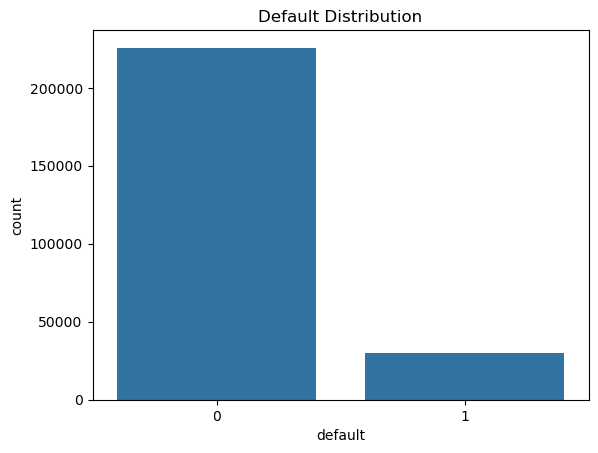

In [16]:
sns.countplot(x='default', data=df)
plt.title("Default Distribution")
plt.show()

#### Insights 
-Majority of customers are non-defaulters (0), showing a strong imbalance

-Defaulters (1) are very low compared to non-defaulters

-This indicates that default cases are rare but critical

-Model training must handle class imbalance carefully

##### Default Rate %

In [17]:
default_rate = df['default'].mean() * 100
print(f"Default Rate: {default_rate:.2f}%")

Default Rate: 11.61%


### Numerical Feature Analysis

##### Distribution of Key Features

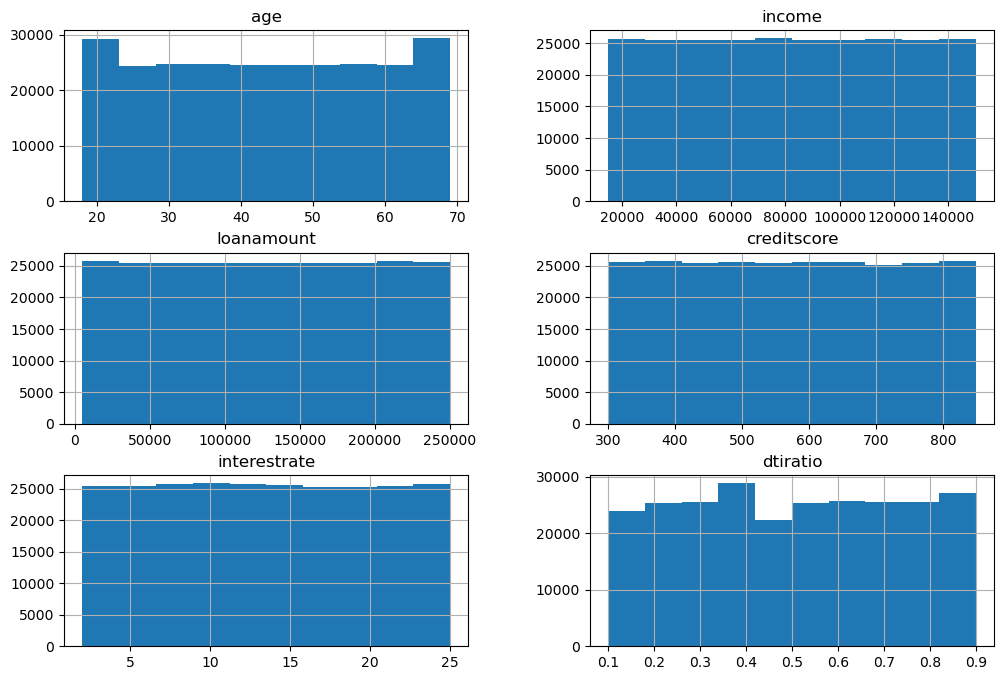

In [18]:
num_cols = ['age','income','loanamount','creditscore','interestrate','dtiratio']

df[num_cols].hist(figsize=(12,8))
plt.show()

#### Insights
-Age is fairly evenly distributed → no strong age bias in dataset

-Income is uniformly spread → dataset includes all income groups

-Loan Amount is well distributed → covers small to large loans

-Credit Score is evenly spread → good variation for risk analysis

-Interest Rate shows balanced distribution → no extreme skew

-DTI Ratio is slightly varied but covers full range → useful for financial stress analysis

##### Default vs Numerical Features


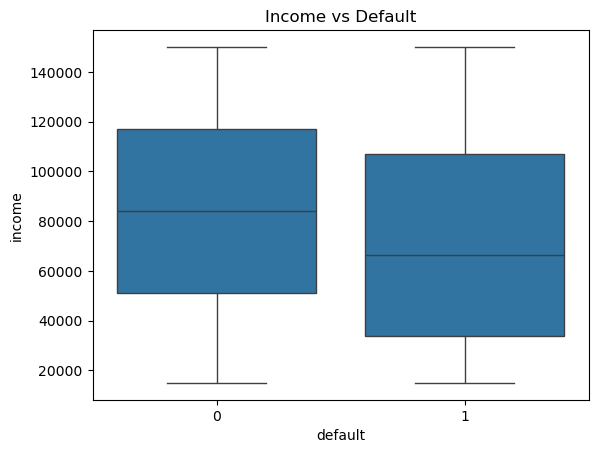

In [19]:
sns.boxplot(x='default', y='income', data=df)
plt.title("Income vs Default")
plt.show()

#### Insights
Defaulters (1) generally have lower median income compared to non-defaulters (0)

Higher income customers are less likely to default

Wider spread in defaulters shows income instability contributes to risk

##### Credit Score vs Default

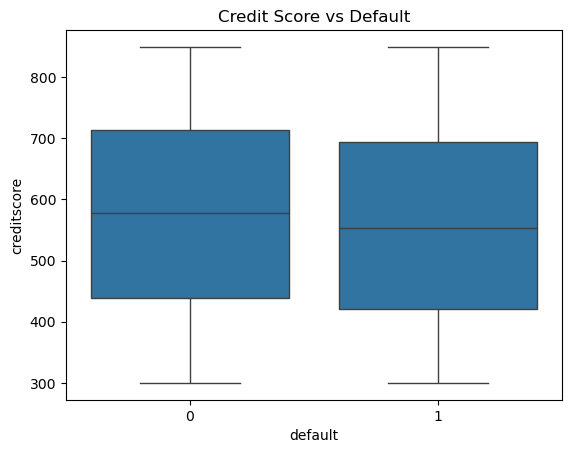

In [20]:
sns.boxplot(x='default', y='creditscore', data=df)
plt.title("Credit Score vs Default")
plt.show()

#### Insights
Defaulters (1) have slightly lower median credit scores than non-defaulters (0)

Lower credit score customers are more likely to default

Higher credit score range is dominated by non-defaulters

##### Loan Amount vs Default

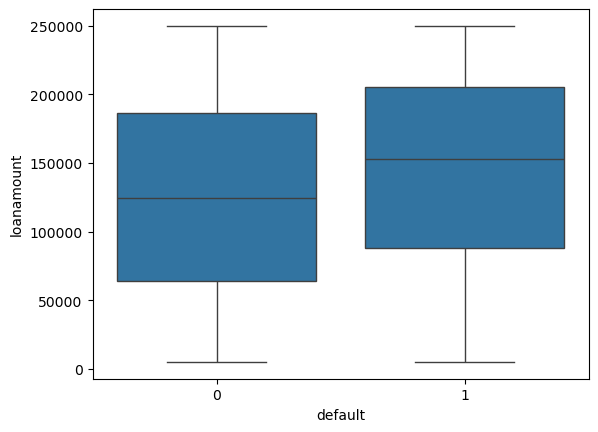

In [21]:
sns.boxplot(x='default', y='loanamount', data=df)
plt.show()

#### Insights
Defaulters (1) have higher median loan amounts compared to non-defaulters (0)

Higher loan amounts are associated with increased default risk

Larger loans may create higher repayment burden, leading to defaults

##### DTI Ratio vs Default

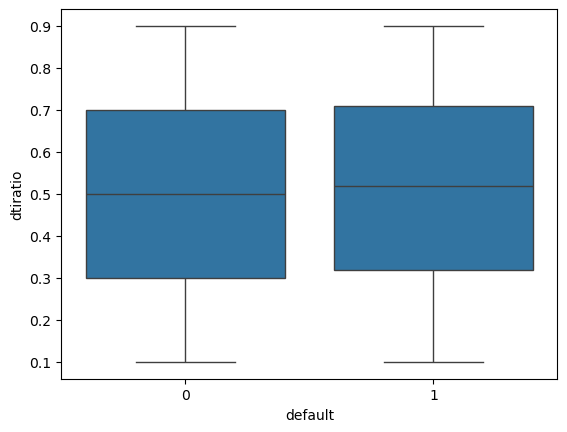

In [22]:
sns.boxplot(x='default', y='dtiratio', data=df)
plt.show()

#### Insights
Defaulters (1) have a slightly higher median DTI ratio than non-defaulters (0)

Higher DTI indicates more financial burden, increasing default risk

Overlap exists, but trend shows higher DTI → higher default probability

### Categorical Analysis

##### Employment Type vs Default

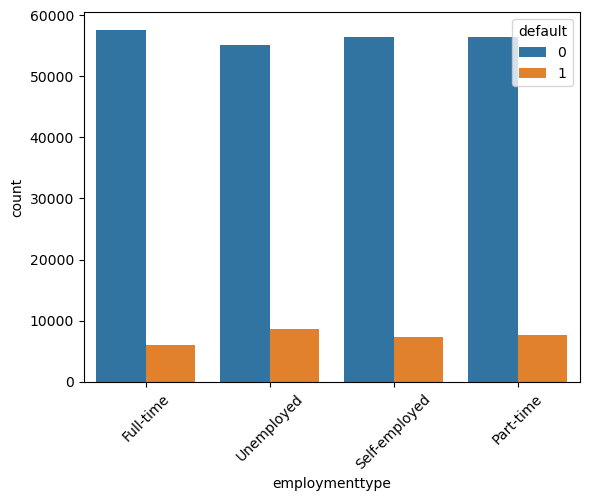

In [23]:
sns.countplot(x='employmenttype', hue='default', data=df)
plt.xticks(rotation=45)
plt.show()


#### Insights
Unemployed customers have the highest default count, indicating highest risk

Full-time employees show the lowest defaults, making them more reliable

Self-employed and part-time groups have moderate default levels

Employment stability clearly impacts repayment behavior

##### Education vs Default

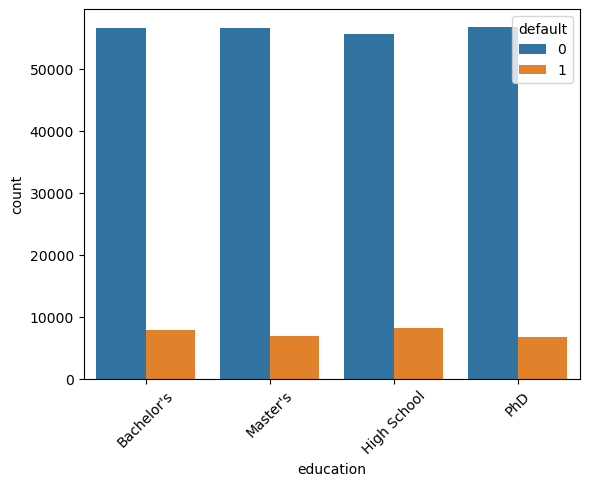

In [24]:
sns.countplot(x='education', hue='default', data=df)
plt.xticks(rotation=45)
plt.show()

#### Insights
Default rates are fairly similar across all education levels

High School group shows slightly higher defaults

Higher education (Master’s, PhD) has slightly lower default counts

Education alone is not a strong predictor of default

##### Loan Purpose vs Default

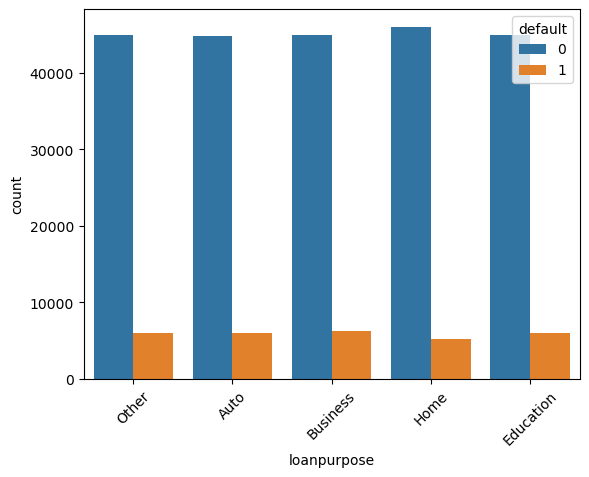

In [25]:
sns.countplot(x='loanpurpose', hue='default', data=df)
plt.xticks(rotation=45)
plt.show()

#### Insights 
Default rates are fairly consistent across all loan purposes

Business loans show slightly higher defaults, indicating higher risk

Home loans have relatively lower defaults, suggesting more stability

No single loan purpose strongly dominates default behavior

##### Marital Status vs Default


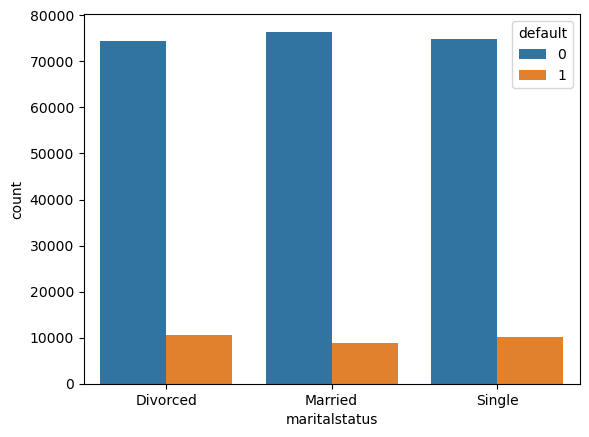

In [26]:
sns.countplot(x='maritalstatus', hue='default', data=df)
plt.show()

#### Insights
Default rates are similar across all marital groups

Married customers show slightly lower defaults, indicating more stability

Single and divorced groups have slightly higher default counts

Marital status has limited impact on default behavior

### Feature Engineering 

##### Income Group

In [27]:
df['income_group'] = pd.cut(df['income'],
                           bins=[0,30000,70000,150000,1000000],
                           labels=['Low','Medium','High','Very High'])

##### Credit Score Group

In [28]:
df['credit_group'] = pd.cut(df['creditscore'],
                           bins=[300,580,670,740,850],
                           labels=['Poor','Fair','Good','Excellent'])

##### Risk Flag

In [29]:
df['high_risk'] = ((df['creditscore'] < 600) & (df['dtiratio'] > 0.5)).astype(int)

#### Insights 
Income grouping helps identify that low-income customers fall into higher risk categories

Credit score grouping clearly separates high-risk (Poor/Fair) and low-risk (Good/Excellent) customers

The high_risk flag effectively captures risky customers using low credit score and high DTI

Combining multiple factors (credit score + DTI) gives better risk identification than single features

### Business Insights

In [30]:
df.groupby('income_group', observed=True)['default'].agg(['count','mean'])

,count,mean
income_group,,
Low,28405,0.219574
Medium,75440,0.121964
High,151502,0.093827


In [31]:
df.groupby('credit_group', observed=True)['default'].mean()

credit_group
Poor         0.124647
Fair         0.114239
Good         0.106280
Excellent    0.101672
Name: default, dtype: float64

In [32]:
df.groupby('employmenttype')['default'].mean()

employmenttype
Full-time        0.094634
Part-time        0.119652
Self-employed    0.114620
Unemployed       0.135529
Name: default, dtype: float64

In [33]:
df.groupby('loanpurpose')['default'].mean()

loanpurpose
Auto         0.118814
Business     0.123260
Education    0.118381
Home         0.102348
Other        0.117885
Name: default, dtype: float64

#### Insights 
##### Income Group

-Default rate is highest in Low income (21.9%)

-Default risk decreases as income increases → High income has lowest risk (~9.3%)

##### Credit Group

-Poor credit group has highest default rate (12.4%)

-Default risk gradually decreases towards Excellent credit (10.1%)

##### Employment Type

-Unemployed customers have highest default rate (13.5%)

-Full-time employees have lowest risk (~9.4%)

##### Loan Purpose

-Business loans show highest default rate (~12.3%)

-Home loans have lowest default rate (~10.2%)

-Other categories are relatively similar

#### Risk Score

In [34]:
df['risk_score'] = (
    (1 / df['creditscore']) * 100 + 
    df['dtiratio'] * 100 + 
    (1 / df['income']) * 10000
)

##### Create Risk Categories

In [35]:
df['risk_category'] = pd.qcut(df['risk_score'], 4,
                             labels=['Low Risk','Medium Risk','High Risk','Very High Risk'])

##### Analyze

In [36]:
df.groupby('risk_category', observed=True)['default'].mean()

risk_category
Low Risk          0.105957
Medium Risk       0.115106
High Risk         0.119854
Very High Risk    0.123596
Name: default, dtype: float64

#### Insights
Default rate increases consistently with risk category

Low Risk → ~10.6% default, while Very High Risk → ~12.3% default

Risk score successfully captures financial stress and credit weakness

Clear upward trend shows model logic is working correctly


#### Stability Analysis

In [37]:
df.groupby(['employmenttype','credit_group'], observed=True)['default'].mean().unstack()

credit_group,Poor,Fair,Good,Excellent
employmenttype,,,,
Full-time,0.101867,0.092956,0.084243,0.084054
Part-time,0.127264,0.120313,0.111873,0.103323
Self-employed,0.124168,0.110407,0.105774,0.098960
Unemployed,0.145470,0.133046,0.123003,0.119888


#### Approval Strategy Simulation

In [38]:
approved = df[df['creditscore'] > 600]
approved['default'].mean()

np.float64(0.10596370820984766)

#### Loss Estimation 

In [39]:
total_loss = df[df['default']==1]['loanamount'].sum()
print(total_loss)

4285312531


##### Risk by Segment

In [40]:
df.groupby('credit_group', observed=True).apply(
    lambda x: x[x['default']==1]['loanamount'].sum()
)

C:\Users\deepk\AppData\Local\Temp\ipykernel_5420\677801582.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('credit_group', observed=True).apply(


credit_group
Poor         2339403572
Fair          690458946
Good          495254489
Excellent     748878907
dtype: int64

#### Insights (Loss Estimation & Risk Segments)
Total estimated loss due to defaults is ~4.28 Billion, showing significant financial impact

Poor credit group contributes the highest loss (~2.33B) despite fewer customers

Fair, Good, and Excellent groups contribute progressively lower losses

Unemployed + Poor credit customers have the highest default rates (~14.5%), making them the riskiest segment

Full-time + Excellent credit customers show lowest default risk (~8.4%)

Default risk decreases consistently as credit score improves across all employment types

Employment stability plays a key role:
Unemployed → highest risk
Full-time → lowest risk

#### Profitability

In [41]:
df['estimated_profit'] = df['loanamount'] * df['interestrate'] / 100

In [42]:
df['net_value'] = df.apply(
    lambda x: -x['loanamount'] if x['default']==1 else x['estimated_profit'],
    axis=1
)


In [43]:
df['net_value'].sum()


np.float64(-569773985.6465)

#### Insights
Total net value is negative (~ -569M), indicating overall loss in lending business

Losses from defaulters outweigh the interest earned from non-defaulters

Current interest rates are not sufficient to cover default losses

High default segments are reducing overall profitability

### Correlation Analysis

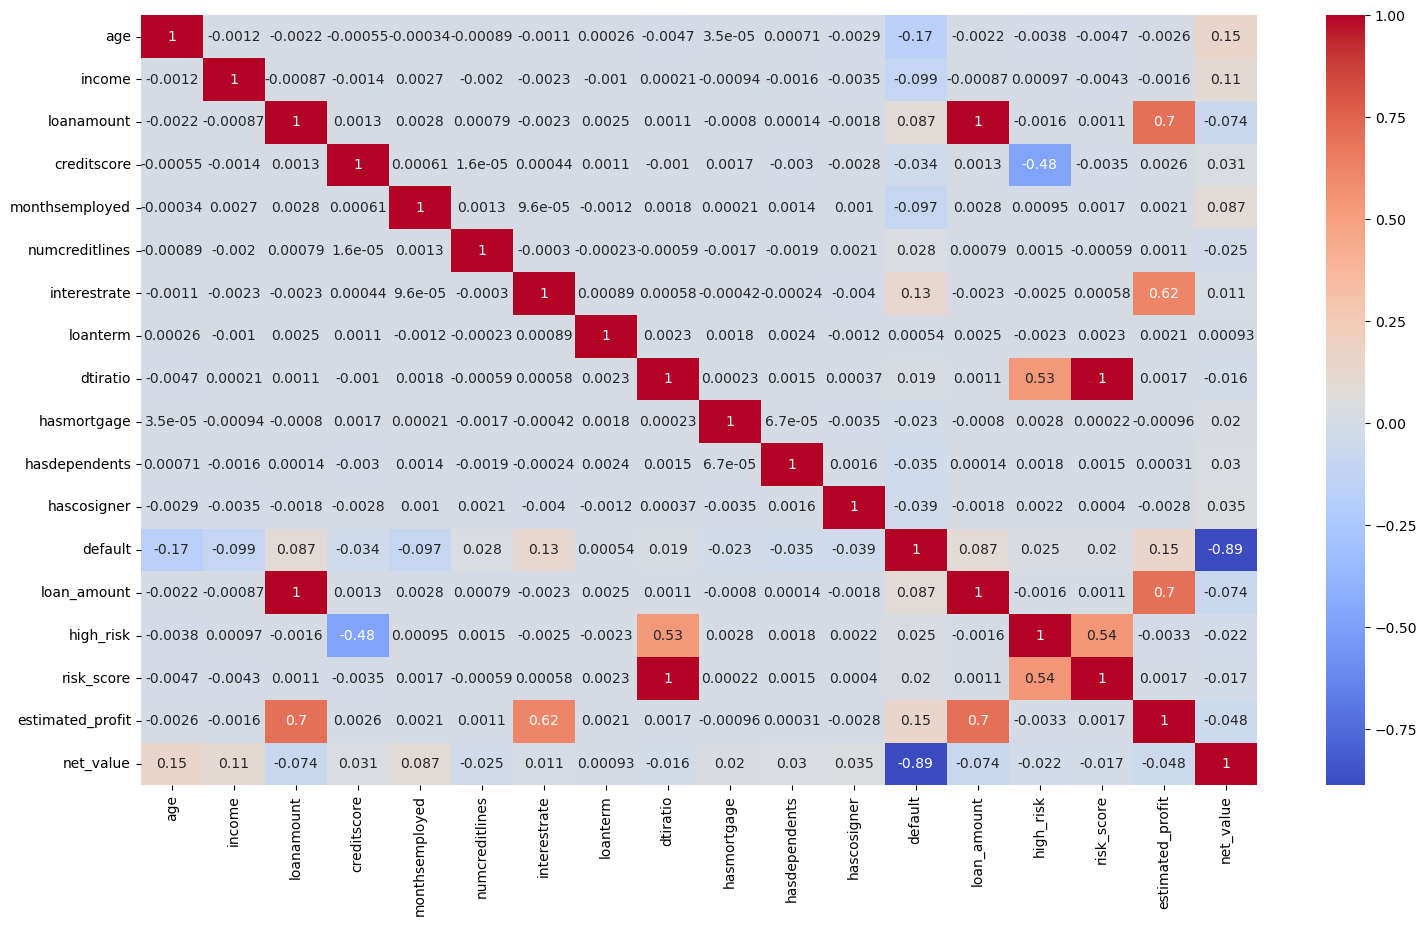

In [45]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(18,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

#### Insights 
Default has negative correlation with credit score (-0.17) → lower score increases default risk

Default slightly increases with interest rate (0.13) → risk-based pricing effect

Income (-0.099) and employment (-0.097) show negative relation with default → stability reduces risk

Strong correlation between loan amount & estimated profit (0.70) → bigger loans generate more profit

Interest rate also strongly impacts profit (0.62)

DTI ratio is positively correlated with risk score (0.53) → higher financial burden increases risk

Risk score and high_risk flag are strongly related (0.54) → feature engineering is effective

Default vs Net Value (-0.89) shows strong negative impact → defaults drive losses